In [1]:
import numpy as np
import sys
sys.path.append('..')
from custom_lib import quantum_circuit_ctx_generator, utils, verilog, fixed_point_handler

In [20]:
min_qbit_num = 3
max_qbit_num = 17
min_quanv = 1
max_quanv = 19

quanv_range = np.arange(min_quanv, max_quanv+1, 1)
qubit_num_range = np.arange(min_qbit_num, max_qbit_num+1, 1)

num_mem_state_quanv = np.zeros((len(qubit_num_range), len(quanv_range)))
num_mem_gate_quanv = np.zeros((len(qubit_num_range), len(quanv_range)))

for i, qubit_num in enumerate(qubit_num_range):
    for j, quanv_num in enumerate(quanv_range):
        num_mem_state_quanv[i,j] = 2**qubit_num * (64/8) # Bytes

        tmp_file = utils.read_file(file_name=f'../hardware/gate_ctx_for_sim/quantum_circuit_data_{qubit_num}_qubits/output_hex_{qubit_num}_qubits_quanvolutional_{quanv_num}.txt')
        tmp_file_len = len(tmp_file)
        num_mem_gate_quanv[i,j] = tmp_file_len * (64/8) + 4* 4 * (64/8) # Bytes

software_estimate = np.zeros((len(qubit_num_range)))
for i, qubit_num in enumerate(qubit_num_range):
    software_estimate[i] = (2**qubit_num * (2**qubit_num + 1)) * (64/8) # Bytes

C:\Users\haime\AppData\Local\Temp\ipykernel_36704\1029059524.py:22: RuntimeWarning: overflow encountered in scalar multiply
  software_estimate[i] = (2**qubit_num * (2**qubit_num + 1)) * (64/8) # Bytes


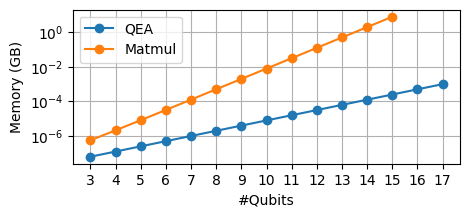

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 2))

ax.plot(qubit_num_range, num_mem_state_quanv[:,0]*(9.3132257461548E-10), label=f'QEA', marker='o')
ax.plot(qubit_num_range[:13], software_estimate[:13]*(9.3132257461548E-10), label=f'Matmul', marker='o')
ax.set(xlabel='#Qubits', ylabel='Memory (GB)')
ax.set_yscale('log')
ax.set_xticks(qubit_num_range)
ax.set_xticklabels(qubit_num_range)
ax.legend()
ax.grid()
plt.savefig('../images/memory_vs_qubit_num.svg', bbox_inches='tight')